# Use the controller, step by step

A first session on a microscope, from Python. Everything here runs on the
**mock driver**, a simulated microscope that comes with the controller. It
moves, takes real pictures of a pretend slide with fluorescent spots, blurs
when out of focus, and refuses moves beyond its limits. You need no
microscope. On a real microscope, only step 1 changes.

The [README](README.md) of this part is the complete reference of every
command.

**Before you start**

- Python 3.11 or newer, with the controller installed:
  `pip install "git+https://github.com/thomdehoog/ZMART-controller"`
- To look at the pictures inside this notebook: `pip install tifffile matplotlib`.
  Without them, open the saved files in [Fiji](https://fiji.sc) or
  [napari](https://napari.org) instead.

Run the cells one at a time, from top to bottom.

## The idea

Every microscope comes with its own software and its own way of being
programmed. The ZMART Controller puts one short list of plain commands in
front of all of them: move, read and apply the settings, take a picture, run
a routine such as autofocus. A **driver** translates these commands for one
particular microscope.

```
your Python ──► zmart_controller ──► driver ──► microscope
```

## Step 1: plug in a driver

`get_drivers` lists the drivers registered on this computer. The mock driver
is always there.

In [1]:
import zmart_controller

zmart_controller.get_drivers()

['mock']

`set_instrument` plugs in a driver and connects to its microscope. From now
on, every command you call on `zmart_controller` goes to this microscope.

The second argument is optional. Here it tells the mock to save its images in
a folder called `images`, next to this notebook.

In [2]:
zmart_controller.set_instrument("mock", {"output_root": "images"})
zmart_controller.get_info()["content"]["output_root"]

'images'

## Step 2: meet the microscope

Every command answers with the same two things: `success`, which says whether
the driver did what you asked, and `content`, which is what it has to say.

The `description` in `get_info` is the microscope in plain words. Read it
whenever you meet a new microscope.

In [3]:
print(zmart_controller.get_info()["content"]["description"])

A pretend widefield fluorescence microscope that runs entirely in software (MockScope Control), for trying workflows without hardware. It images a sample of scattered fluorescent spots on a slide that is slightly tilted, so the height at which the spots are sharp changes a little from place to place.

Stage: x and y move the slide, z moves the focus, all in micrometres from the origin. z has two motors: "motoric" for long moves and "piezo" for fine, fast steps around the current height.

Objectives, by slot: 1 is 10x/0.30 Air (1.0 µm per pixel), 2 is 20x/0.75 Air (0.5 µm per pixel), 3 is 40x/0.95 Air (0.25 µm per pixel). Every image is 64 x 64 pixels, so the field of view shrinks as the magnification grows. Changing objective shifts the view slightly; the driver corrects for it.

Settings (the changeable part of the state): objective is the slot number above; laser_power is the excitation in percent, 0 to 50; gain is the detector gain, 0 to 800; exposure_ms is the exposure time in mill

## Step 3: where is the stage?

Positions are in micrometres from the **origin**, a point (0, 0, 0) that was
chosen once for this microscope. For each axis, `value` is where the stage is
now and `canvas` is everywhere a picture can show. On the mock, the stage
travels 5 mm to either side in x and y, and 0.5 mm in z. A picture at the
edge shows another 32 µm beyond it.

In [4]:
zmart_controller.get_xyz()["content"]

{'x': {'value': 0.0, 'actuator': 'motoric', 'canvas': [-5032.0, 5032.0]},
 'y': {'value': 0.0, 'actuator': 'motoric', 'canvas': [-5032.0, 5032.0]},
 'z': {'value': 0.0, 'actuator': 'motoric', 'canvas': [-500.0, 500.0]}}

## Step 4: move

`set_xyz` always takes all three axes, in micrometres from the origin. It
returns once the stage has arrived.

In [5]:
zmart_controller.set_xyz(100, 50, 0)
zmart_controller.get_xyz()["content"]["x"]["value"]

100.0

Now ask for a move that is too far. The driver checks every move against the
limits before sending it, so nothing moves.

The `try` and `except` lines catch the error so that you can read its
message. Without them the notebook shows the full error and stops the cell.
The mock also writes the refusal to its log, so the message appears twice.

In [6]:
try:
    zmart_controller.set_xyz(99999, 0, 0)
except ValueError as error:
    print(error)

move refused by the limits: x would go to 149999.00 µm (stage coordinates), outside the travel range [45000.0, 55000.0] set in the limits


move refused: x would go to 149999.00 µm (stage coordinates), outside the travel range [45000.0, 55000.0] set in the limits


The message counts in the stage's own coordinates, where the limits are set.
Those numbers differ from yours by the origin.

One more thing about directions: **in a saved image, right is +x and down is
+y**, on every microscope. A picture taken at a larger x shows what lay to
the right.

## Step 5: look at the settings and change one

The *state* has two parts. `changeable` holds the settings you can change.
`observed` describes the microscope as it is, such as the objective's name and
the pixel size, and is only for reading.

In [7]:
state = zmart_controller.get_state()["content"]
state["changeable"]

{'laser_power': 10.0, 'gain': 100.0, 'exposure_ms': 10.0, 'objective': 1}

To change a setting, edit the state and apply it.

In [8]:
state["changeable"]["laser_power"] = 20.0
zmart_controller.set_state(state)["content"]["applied"]

{'objective': 1, 'laser_power': 20.0, 'gain': 100.0, 'exposure_ms': 10.0}

You can also apply only the settings you name. The others stay as they are.

In [9]:
zmart_controller.set_state({"changeable": {"exposure_ms": 20.0}})["content"]["applied"]

{'exposure_ms': 20.0}

Keep a captured state in a variable, and one `set_state` puts the microscope
back into exactly those settings later.

## Step 6: take a picture

`acquire` captures an image with the current settings at the current
position, and saves it. `position_label` names the position in the saved
files. The answer lists every file it saved under `files`: here the image,
and a log of the commands the mock sent to make it.

In [10]:
answer = zmart_controller.acquire(position_label="first")
answer["content"]["files"]

['images/first.ome.tif', 'images/first.commands.json']

The answer also says where on the sample the picture was taken, under
`planes`. `c`, `z` and `t` are the channel, depth and time point, counted
from 0. `x_um`, `y_um` and `z_um` are the stage position in micrometres.

In [11]:
answer["content"]["planes"]

[{'path': 'images/first.ome.tif',
  'c': 0,
  'z': 0,
  't': 0,
  'x_um': 100.0,
  'y_um': 50.0,
  'z_um': 0.0}]

Have a look at the picture. You should see small bright spots, like
fluorescent beads.

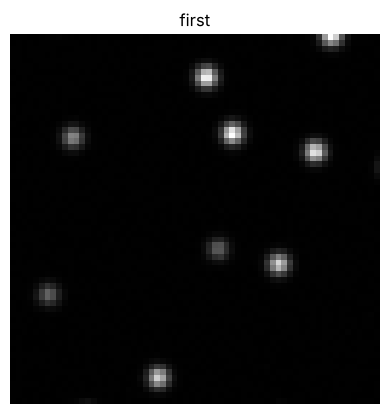

In [12]:
import matplotlib.pyplot as plt
import tifffile

image = tifffile.imread(answer["content"]["planes"][0]["path"])
plt.imshow(image, cmap="gray")
plt.title("first")
plt.axis("off")
plt.show()

Take the same label again and nothing is overwritten. The second picture is
saved as `first_001`.

In [13]:
zmart_controller.acquire(position_label="first")["content"]["files"]

['images/first_001.ome.tif', 'images/first_001.commands.json']

## Step 7: a z-stack

A z-stack is a series of pictures at different heights. The choices for *how*
to capture and save are the **acquisition settings**. Each driver offers its
own. `get_acquisition_settings` lists them, with the values each may take and
the value used when you say nothing.

In [14]:
zmart_controller.get_acquisition_settings()["content"]

{'folder': {'options': 'any text; empty saves straight into output_root',
  'active': ''},
 'backlash_correction': {'options': [True, False], 'active': True},
 'format': {'options': ['ome-tiff', 'ome-zarr'], 'active': 'ome-tiff'},
 'z_planes': {'options': 'whole number from 1 up to the limit', 'active': 1},
 'z_step_um': {'options': 'number > 0', 'active': 1.0}}

On the mock, a z-stack is chosen with `z_planes` and `z_step_um`. We also
put it in a folder of its own. Settings you leave out keep their active
value, so the next `acquire` without settings takes a single plane again.

In [15]:
answer = zmart_controller.acquire(
    position_label="stack",
    acquisition_settings={"z_planes": 5, "z_step_um": 2.0, "folder": "stacks"},
)
for plane in answer["content"]["planes"]:
    print(plane["z"], plane["z_um"], plane["path"])

0 0.0 images/stacks/stack_z000.ome.tif
1 2.0 images/stacks/stack_z001.ome.tif
2 4.0 images/stacks/stack_z002.ome.tif
3 6.0 images/stacks/stack_z003.ome.tif
4 8.0 images/stacks/stack_z004.ome.tif


The stack starts at the current height and goes up. The spots are sharp in
the first plane and blur as the focus moves away.

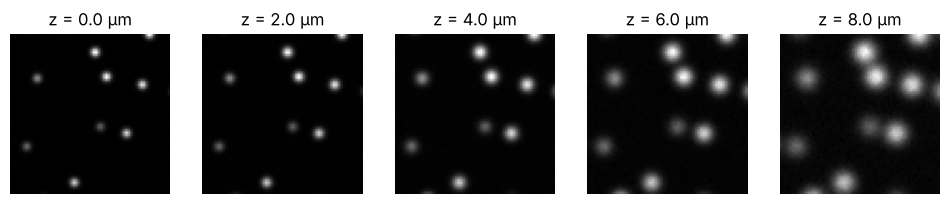

In [16]:
planes = answer["content"]["planes"]
figure, axes = plt.subplots(1, len(planes), figsize=(12, 3))
for axis, plane in zip(axes, planes, strict=True):
    axis.imshow(tifffile.imread(plane["path"]), cmap="gray")
    axis.set_title(f"z = {plane['z_um']} µm")
    axis.axis("off")
plt.show()

## Step 8: run autofocus

The microscope offers a few routines of its own, called **procedures**.

In [17]:
for name, procedure in zmart_controller.get_procedures()["content"].items():
    print(f"{name}: {procedure['description']}")

autofocus: Take a short z-stack around the current height, find the sharpest plane, and move there. Optional: range_um (default 20), step_um (default 2).
backlash_takeup: Approach the current position from the same side every time, so that positions repeat exactly.
zero_piezo: Move the piezo to the middle of its range, keeping the focus height.


Move the focus 6 µm away, run autofocus, and see where it put the focus.
Options go in the same dictionary as the name, for example
`{"name": "autofocus", "range_um": 10, "step_um": 1}`.

In [18]:
zmart_controller.set_xyz(100, 50, 6)
zmart_controller.run_procedure({"name": "autofocus"})
zmart_controller.get_xyz()["content"]["z"]["value"]

0.0

## Step 9: disconnect

This closes the connection. Any command now raises an error that tells you to
call `set_instrument` first.

In [19]:
zmart_controller.disconnect()

## When something goes wrong

Three kinds of outcome can come back besides plain success. Each tells you
where to look.

| Outcome | Meaning | What to do |
|---|---|---|
| `ValueError` | Your request was wrong. Nothing was done | Fix the call. The matching `get_*` command shows what is allowed |
| `RuntimeError` | The microscope failed or refused | Look at the microscope and its software |
| `success: False` | Not what you asked, but safe to carry on | Read the reason in `content` |

## Small scripts to adapt

A script is a session like the one above, written in a file and run with
`python myscript.py`. Each one below plugs in the mock. On a real microscope,
plug in its driver instead and keep the rest.

**A row of positions, one picture each.**

In [20]:
zmart_controller.set_instrument("mock", {"output_root": "images"})

for i in range(5):
    zmart_controller.set_xyz(i * 200, 0, 0)  # 200 µm apart
    zmart_controller.acquire(position_label=f"row_{i}")

zmart_controller.disconnect()

**A grid, saved in its own folder.** One step is one field of view of the
10x objective, so the pictures just touch.

In [21]:
zmart_controller.set_instrument("mock", {"output_root": "images"})

step = 64
grid = {}
for row in range(3):
    for column in range(3):
        zmart_controller.set_xyz(column * step, row * step, 0)
        answer = zmart_controller.acquire(
            position_label=f"r{row}_c{column}",
            acquisition_settings={"folder": "grid"},
        )
        grid[row, column] = answer["content"]["planes"][0]["path"]

zmart_controller.disconnect()

Because right is +x and down is +y, `r0_c1` lies directly to the right of
`r0_c0`, and `r1_c0` directly below it. Laid out that way, the nine pictures
tile the specimen.

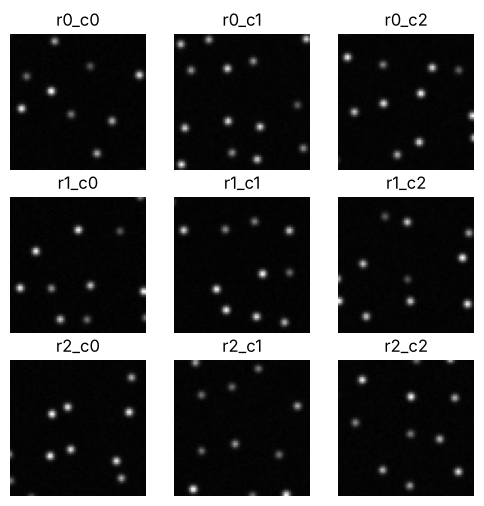

In [22]:
figure, axes = plt.subplots(3, 3, figsize=(6, 6))
for (row, column), path in grid.items():
    axes[row, column].imshow(tifffile.imread(path), cmap="gray")
    axes[row, column].set_title(f"r{row}_c{column}")
    axes[row, column].axis("off")
plt.show()

**Save the settings to a file, and apply them again another day.**

In [23]:
import json

zmart_controller.set_instrument("mock", {"output_root": "images"})

# Today: capture the settings you are happy with.
state = zmart_controller.get_state()["content"]
with open("my_settings.json", "w") as file:
    json.dump(state, file, indent=2)

# Another day: put the microscope back into exactly these settings.
with open("my_settings.json") as file:
    zmart_controller.set_state(json.load(file))

zmart_controller.disconnect()

**A time series at one position.**

In [24]:
import time

zmart_controller.set_instrument("mock", {"output_root": "images"})

for t in range(3):  # three pictures, 2 seconds apart
    zmart_controller.acquire(
        position_label=f"t{t:03d}",
        acquisition_settings={"folder": "timeseries"},
    )
    time.sleep(2)

zmart_controller.disconnect()

**Check the answer before carrying on.**

In [25]:
zmart_controller.set_instrument("mock", {"output_root": "images"})

answer = zmart_controller.acquire(position_label="checked")
if answer["success"]:
    print("saved:", answer["content"]["files"])
else:
    print("not saved:", answer["content"])

zmart_controller.disconnect()

saved: ['images/checked.ome.tif', 'images/checked.commands.json']


## Good to know

- **Every command waits until it is done.** When `set_xyz` returns, the stage
  has arrived. When `acquire` returns, the files are saved.
- **Units.** Positions and steps are in micrometres. The `description` gives
  the units of the settings, such as milliseconds for `exposure_ms`.
- **Use the paths from `files`.** Where a microscope saves its pictures is up
  to its driver. The paths in the answer are always right.
- **Names of settings and procedures belong to the microscope.** The mock's
  `laser_power`, `folder` or `autofocus` may be called differently, or not
  exist, on another microscope. Look them up with `get_state`,
  `get_acquisition_settings` and `get_procedures`.
- **A faster mock.** The mock takes a little time for every move and picture,
  like a real microscope. For quick tests, plug it in with
  `{"mock_timing": "instant"}`.

## Where to go next

- The [README](README.md) of this part: every command, every answer, and
  what works on every microscope.
- Part 1, [Plug in a driver](../1_plug_in_a_driver/README.md): how drivers
  work, and how to write one for your own microscope.

---

MIT license. Thom de Hoog, Center for Microscopy and Image Analysis (ZMB), University of Zurich. thom.dehoog@zmb.uzh.ch, thomdehoog@gmail.com.